In [1]:
# Standard libraries
import os
import random
import numpy as np
import pandas as pd

# For preprocessing
import re
import string

# For tokenization & embeddings
from sentence_transformers import SentenceTransformer

# For classification
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score, roc_auc_score

# For visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Plot settings
sns.set(style='whitegrid')
%matplotlib inline

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)


/home/kefan/miniconda3/envs/slanggen/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Load CSV
df = pd.read_csv("Def_Pairs_Paraphrased.csv")

# Show a few examples
print("Sample rows:")
display(df.head())

# Check label distribution
print("\nLabel distribution:")
print(df["term_lang"].value_counts())


Sample rows:


,term_lang,word,conv_def,slang_def,conv_def_paraphrased,slang_def_paraphrased
0,ZH,阿乡,A person from a rural area who is considered u...,country bumpkin; yokel,An individual originating from the countryside...,A folksy term for someone seen as a hick or ru...
1,ZH,挨呲儿,to be scolded; to receive a reprimand,get a talking-to; get a dressing down,to be criticized or reproached by someone; to ...,to get chewed out or told off; to catch a scol...
2,ZH,挨剋,"To be scolded, reprimanded, or criticized by s...",get a talking-to; told off; get a dressing-down,"To receive criticism, a reprimand, or a scoldi...",to get chewed out; to be given a good telling-...
3,ZH,案子,A legal case; a matter under investigation or ...,case; law case,A legal matter that is being examined or decid...,An informal way to refer to a court case or le...
4,ZH,吧嗒,To puff on or draw from a pipe (for smoking).,pull at (a pipe); smoke (a pipe),To inhale or take a drag from a pipe when smok...,To casually take a puff from a pipe; to have a...



Label distribution:
term_lang
RU    1017
EN     899
ZH     643
Name: count, dtype: int64


In [3]:
# Load SBERT model
sbert_model = SentenceTransformer("bert-base-nli-mean-tokens") 

# Combine conv + slang definitions into one string
combined_texts = df["conv_def_paraphrased"] + " [SEP] " + df["slang_def_paraphrased"]

# Compute embeddings
print("Encoding definitions...")
X = sbert_model.encode(combined_texts.tolist(), batch_size=32, show_progress_bar=True)

# Convert labels to binary: en -> 0, zh -> 1, ru -> 2
label_map = {"EN": 0, "ZH": 1, "RU":2}
y = df["term_lang"].map(label_map).values


/home/kefan/miniconda3/envs/slanggen/lib/python3.10/site-packages/huggingface_hub/file_download.py:943: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


Encoding definitions...


Batches: 100%|███████████████████████████████████████████████████████████████████████████████████| 80/80 [00:00<00:00, 87.50it/s]


Labels: ['EN', 'ZH', 'RU']
Accuracy: 0.7695
F1 Score: 0.7696
Labels: ['EN', 'ZH']
Accuracy: 0.8581
F1 Score: 0.8583
Labels: ['ZH', 'RU']
Accuracy: 0.8675
F1 Score: 0.8666
Labels: ['EN', 'RU']
Accuracy: 0.8906
F1 Score: 0.8906


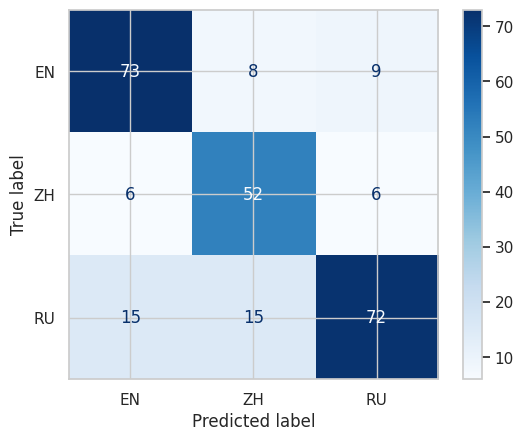

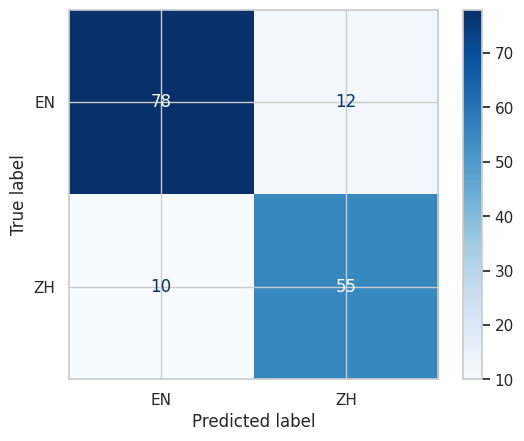

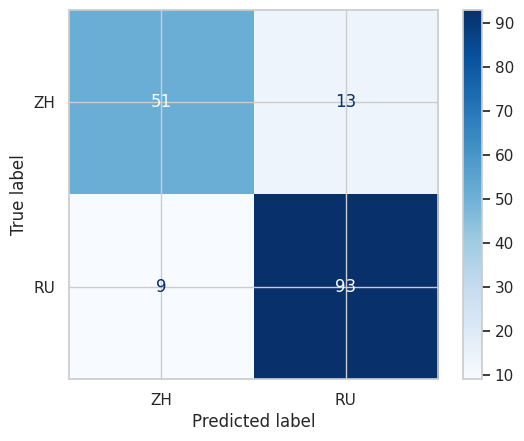

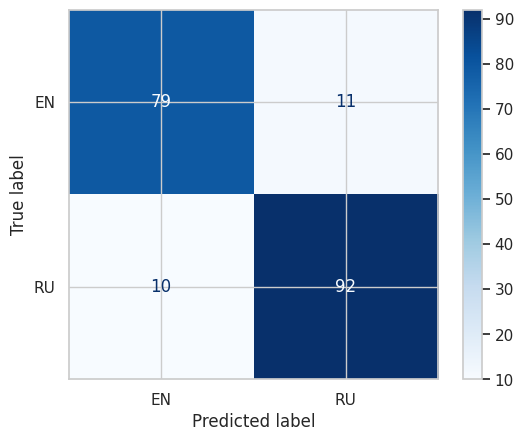

In [4]:
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, ConfusionMatrixDisplay

def run_classifier(X, y, labels, test_size=0.1):
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=42, stratify=y
    )
    clf = LogisticRegression(max_iter=2500)
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)
    
    print(f"Labels: {labels}")
    print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
    print(f"F1 Score: {f1_score(y_test, y_pred, average='weighted'):.4f}")
    
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
    disp.plot(cmap="Blues")

run_classifier(X, y, labels=["EN", "ZH", "RU"])

pairs = [(0, 1), (1, 2), (0, 2)]
for a, b in pairs:
    mask = np.isin(y, [a, b])
    run_classifier(X[mask], y[mask], labels=[list(label_map.keys())[a], list(label_map.keys())[b]])
